# ES, EnIF, and EnIF-MDA on a linear model

PET's `LinearModel` observes selected positions of a one-dimensional field. Here we use a small, correlated version of that problem so the exact Gaussian posterior is available for comparison. We run a sample-covariance **ensemble smoother (ES)**, **ERT's actual EnIF analysis**, and its five-step EnIF-MDA path, re-evaluating the linear forward model after each MDA update.

**Prerequisites:** Open this notebook from `DEMO/` or `DEMO/notebooks/` with the project's `.venv` Python and the locally modified ERT fork at `../code/ert/src`. The notebook adds that checkout to `sys.path` before importing ERT; it does not need PET, OPM, or a simulator process.

**Goals:** Understand the prior graph, derive the exact posterior, compare all three methods' mean and standard deviation at every state position, and see the effect of five weighted updates.

## 1. Setup and a PET-style linear example

The unknown field is $x\in\mathbb{R}^8$. Observations pick out three entries: $d=Gx+\varepsilon$, where $\varepsilon\sim\mathcal N(0,R)$ and $R=0.25I$. All three methods start with **the same 800 prior realizations**. The small grid keeps the demonstration fast; unlike PET's original regression test, the reference below is an analytical distribution, not a saved random output.

In [1]:
from pathlib import Path
from types import SimpleNamespace
from uuid import uuid4
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl

project = next((p for p in (Path.cwd(), *Path.cwd().parents)
                if (p / 'benchmark.toml').is_file() and (p / 'src/opm_ert_demo').is_dir()), None)
if project is None:
    raise RuntimeError('Start Jupyter in DEMO/ or DEMO/notebooks/.')
ert_source = project.parent / 'code/ert/src'
if not ert_source.is_dir():
    raise RuntimeError(f'Modified ERT checkout not found: {ert_source}')
sys.path.insert(0, str(ert_source))

from ert.analysis._enif_update import analysis_EnIF
from ert.analysis.snapshots import SmootherSnapshot


In [ ]:
SEED = 10
SIZE, MEMBERS = 8, 5
OBS_INDEX = np.array([1, 4, 6])
OBSERVATIONS = np.array([0.9, -0.6, 1.2])
OBS_STD = np.full(len(OBS_INDEX), 0.5)
PRIOR_MEAN = np.linspace(-0.3, 0.2, SIZE)
positions = np.arange(SIZE)
PRIOR_COV = 0.6 ** np.abs(positions[:, None] - positions[None, :])
WEIGHTS = [5.0] * 5
assert np.isclose(sum(1 / a for a in WEIGHTS), 1.0)

pl.DataFrame({'position': OBS_INDEX, 'observation': OBSERVATIONS, 'error std': OBS_STD})


position,observation,error std
i64,f64,f64
1,0.9,0.5
4,-0.6,0.5
6,1.2,0.5


## 2. Why is the EnIF prior graph a chain?

We chose $C_{ij}=0.6^{|i-j|}$, the covariance of a stationary first-order Markov chain. Its **exact inverse is tridiagonal**: $x_i$ and $x_j$ are conditionally independent given their neighbors when $|i-j|>1$. Thus the prior conditional-independence graph is `nx.path_graph(8)`, with edges only between adjacent positions. This graph constrains EnIF's *estimated prior precision*; it is not the observation operator $G$. EnIF learns a separate sparse response map $H$ from the ensemble. ERT's approximate-Cholesky fit expands graph neighborhoods by two hops internally; posterior precision can acquire additional connections through $H^\mathsf T\Lambda_rH$.

Below, colored nodes are observed and the right panel shows the nonzero pattern of the **analytical prior precision**. In an application, select graph edges from known spatial or physical conditional dependencies rather than from the observations you want to match. ES estimates dense sample covariances directly and does not use this graph.

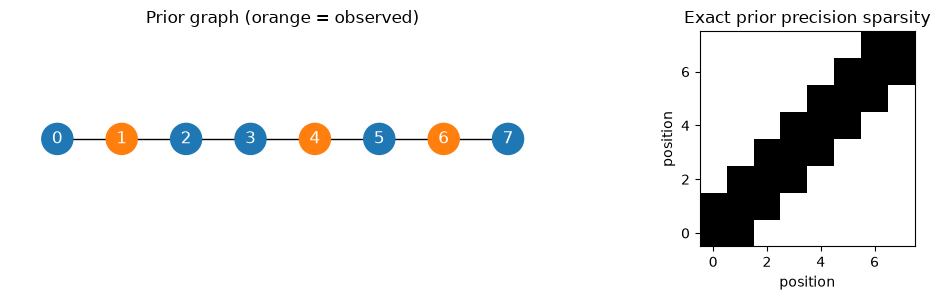

In [3]:
GRAPH = nx.path_graph(SIZE)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.1))
nx.draw_networkx(GRAPH, pos={i: (i, 0) for i in GRAPH}, ax=axes[0],
                 node_color=['tab:orange' if i in OBS_INDEX else 'tab:blue' for i in GRAPH],
                 font_color='white', node_size=500)
axes[0].set_title('Prior graph (orange = observed)')
axes[0].axis('off')
axes[1].imshow(np.abs(np.linalg.inv(PRIOR_COV)) > 1e-10, cmap='Greys',
               origin='lower', vmin=0, vmax=1)
axes[1].set(title='Exact prior precision sparsity', xlabel='position', ylabel='position')
plt.tight_layout()
plt.show()


## 3. Analytical Gaussian posterior

Let $m$ and $C$ be the prior mean and covariance. $G$ selects `OBS_INDEX` and $R=\mathrm{diag}(\sigma^2)$. The reference is independent of EnIF and comes from the linear-Gaussian conditioning identities used in PET's `LinearModel/run_script.py`:

$$K=CG^\mathsf T(GCG^\mathsf T+R)^{-1},\qquad m_{\rm post}=m+K(d-Gm),\qquad C_{\rm post}=C-KGC.$$

The plotted standard deviation is $\sqrt{\mathrm{diag}(C_{\rm post})}$; it is **not** an observation error. This exact reference is independent of all three ensemble updates.

In [4]:
cross_cov = PRIOR_COV[:, OBS_INDEX]
observed_cov = PRIOR_COV[np.ix_(OBS_INDEX, OBS_INDEX)]
gain = np.linalg.solve(observed_cov + np.diag(OBS_STD**2), cross_cov.T).T
analytic_mean = PRIOR_MEAN + gain @ (OBSERVATIONS - PRIOR_MEAN[OBS_INDEX])
analytic_cov = PRIOR_COV - gain @ cross_cov.T
analytic_std = np.sqrt(np.diag(analytic_cov))
pl.DataFrame({'position': positions, 'mean': analytic_mean, 'std': analytic_std})


position,mean,std
i64,f64,f64
0,0.227082,0.843471
1,0.649898,0.44548
2,0.239872,0.810868
3,-0.064284,0.810205
4,-0.362726,0.440463
5,0.258287,0.743277
6,0.932938,0.442118
7,0.68262,0.842834


## 4. Connect the linear model to ERT's EnIF analysis

ERT normally loads parameters and simulated responses from storage. This tiny in-memory adapter supplies the same inputs: parameters, observations, a graph, and $h(x)=Gx$ evaluated on whichever ensemble is current. It does **not** replace EnIF's sparse regression, precision estimation, transport, or MDA update. The ES calculation below works directly with NumPy. We draw the prior once and reuse it for all three methods.

In [5]:
config = SimpleNamespace(update_strategy='global', load_parameter_graph=lambda: GRAPH)
experiment = SimpleNamespace(parameter_configuration={'FIELD': config})
prior_draw = np.random.default_rng(SEED).multivariate_normal(
    PRIOR_MEAN, PRIOR_COV, size=MEMBERS).T

class LinearEnsemble:
    def __init__(self, values, name):
        self.parameters = None if values is None else values.copy()
        self.name = name
        self.id = uuid4()
        self.experiment = experiment

    def get_observations_and_responses(self, selected_observations, active_indices):
        return pl.DataFrame({
            'observation_key': ['OBS'] * len(OBS_INDEX),
            'response_key': ['RESP'] * len(OBS_INDEX),
            'index': [str(i) for i in OBS_INDEX],
            'observations': OBSERVATIONS,
            'std': OBS_STD,
            **{str(i): self.parameters[OBS_INDEX, i] for i in active_indices},
        })

    def load_parameters_numpy(self, group, active_indices):
        return self.parameters[:, active_indices].copy()

    def save_parameters_numpy(self, values, group, active_indices):
        self.parameters = values.copy()

def update(source, name, seed, weight=1.0, prior_information=None, mda=False):
    target = LinearEnsemble(None, name)
    snapshot = SmootherSnapshot(source.name, name, -1, -1, weight)
    information = analysis_EnIF(
        ['FIELD'], ['OBS'], seed, snapshot, np.ones(MEMBERS, dtype=bool),
        source, target, lambda event: None, global_scaling=weight,
        prior_information=prior_information, mda=mda,
    )
    return target, information


## 5. Ensemble smoother (ES): one update

A stochastic ES estimates $C_{xy}$ and $C_{yy}$ from the **prior ensemble**, then applies $K_{\rm ES}=C_{xy}(C_{yy}+R)^{-1}$ to each member. Each observed datum is independently perturbed by $\mathcal N(0,R)$ so the ensemble spread represents the posterior rather than only updating its mean. This NumPy implementation follows the standard ES equations; it uses the same prior and observation errors as EnIF, but **no graph or localization**.

In [6]:
es_responses = prior_draw[OBS_INDEX, :]
prior_anomalies = prior_draw - prior_draw.mean(axis=1, keepdims=True)
response_anomalies = es_responses - es_responses.mean(axis=1, keepdims=True)
sample_cross_cov = prior_anomalies @ response_anomalies.T / (MEMBERS - 1)
sample_response_cov = response_anomalies @ response_anomalies.T / (MEMBERS - 1)
es_gain = np.linalg.solve(
    sample_response_cov + np.diag(OBS_STD**2), sample_cross_cov.T).T
es_noise = np.random.default_rng(SEED + 1).normal(
    scale=OBS_STD[:, None], size=(len(OBS_INDEX), MEMBERS))
es_ensemble = prior_draw + es_gain @ (
    OBSERVATIONS[:, None] + es_noise - es_responses)
es_ensemble.shape


(8, 50)

## 6. Regular EnIF: one update

With uninflated observation errors ($\alpha=1$), the one-shot EnIF estimate is the baseline. A finite ensemble and an estimated sparse $H$ make its moments approximate rather than identical to the analytical reference.

In [7]:
enif_ensemble, enif_information = update(
    LinearEnsemble(prior_draw, 'prior_enif'), 'enif', seed=SEED)
enif_ensemble.parameters.shape


Learning sparse linear map for each response: 100%|██████████| 3/3 [00:00<00:00, 1249.17it/s]


Learning precision Cholesky factor row-by-row: 100%|██████████| 8/8 [00:00<00:00, 7303.97it/s]


(8, 50)

## 7. EnIF-MDA: five weighted updates

For five equal steps, $\alpha_k=5$ and $\sum_k\alpha_k^{-1}=1$. Each pass re-evaluates $h(x)=Gx$ on its updated ensemble, re-estimates $H_k$, and uses the preceding pass's posterior precision as its prior. ERT inflates the **full noisy-residual variance**, including unexplained regression residual variance, to make each information contribution one fifth-strength. Each step uses a distinct reproducible noise seed. In the ideal linear-Gaussian limit the five contributions give the same posterior as one update.

In [8]:
source = LinearEnsemble(prior_draw, 'prior_mda')
information = None
mda_history = []
step_seeds = np.random.SeedSequence(SEED).spawn(len(WEIGHTS))
for k, (weight, step_seed) in enumerate(zip(WEIGHTS, step_seeds), start=1):
    source, information = update(
        source, f'mda_{k}', int(step_seed.generate_state(1)[0]),
        weight=weight, prior_information=information, mda=True)
    mda_history.append(source)
mda_ensemble = source
len(mda_history)


Learning sparse linear map for each response: 100%|██████████| 3/3 [00:00<00:00, 5577.53it/s]


5

## 8. Mean and standard deviation at every position

The tables report the analytical posterior, ES, regular EnIF, and EnIF-MDA side by side. Ensemble standard deviations use `ddof=1`. Small differences are expected with 800 realizations; EnIF also estimates $H$ and prior precision. The analytical result has no sampling uncertainty.

In [9]:
enif_mean = enif_ensemble.parameters.mean(axis=1)
enif_std = enif_ensemble.parameters.std(axis=1, ddof=1)
es_mean = es_ensemble.mean(axis=1)
es_std = es_ensemble.std(axis=1, ddof=1)
mda_mean = mda_ensemble.parameters.mean(axis=1)
mda_std = mda_ensemble.parameters.std(axis=1, ddof=1)
mean_summary = pl.DataFrame({
    'position': positions,
    'analytic mean': analytic_mean, 'ES mean': es_mean,
    'EnIF mean': enif_mean, 'EnIF-MDA mean': mda_mean,
})
std_summary = pl.DataFrame({
    'position': positions,
    'analytic std': analytic_std, 'ES std': es_std,
    'EnIF std': enif_std, 'EnIF-MDA std': mda_std,
})
print('Posterior means:')
print(mean_summary)
print('Posterior standard deviations:')
print(std_summary)
for label, mean, std in [('ES', es_mean, es_std),
                         ('EnIF', enif_mean, enif_std),
                         ('EnIF-MDA', mda_mean, mda_std)]:
    print(f'{label}: max |mean - analytic| = {max(abs(mean - analytic_mean)):.3f}, '
          f'max |std - analytic| = {max(abs(std - analytic_std)):.3f}')


Posterior means:
shape: (8, 5)
┌──────────┬───────────────┬───────────┬───────────┬───────────────┐
│ position ┆ analytic mean ┆ ES mean   ┆ EnIF mean ┆ EnIF-MDA mean │
│ ---      ┆ ---           ┆ ---       ┆ ---       ┆ ---           │
│ i64      ┆ f64           ┆ f64       ┆ f64       ┆ f64           │
╞══════════╪═══════════════╪═══════════╪═══════════╪═══════════════╡
│ 0        ┆ 0.227082      ┆ -0.083618 ┆ 0.044648  ┆ 0.041382      │
│ 1        ┆ 0.649898      ┆ 0.552547  ┆ 0.618082  ┆ 0.615998      │
│ 2        ┆ 0.239872      ┆ 0.283642  ┆ 0.244272  ┆ 0.225704      │
│ 3        ┆ -0.064284     ┆ -0.119527 ┆ 0.114311  ┆ 0.038699      │
│ 4        ┆ -0.362726     ┆ -0.153928 ┆ -0.106853 ┆ -0.23129      │
│ 5        ┆ 0.258287      ┆ 0.373868  ┆ 0.46951   ┆ 0.402272      │
│ 6        ┆ 0.932938      ┆ 0.908443  ┆ 1.046193  ┆ 0.997932      │
│ 7        ┆ 0.68262       ┆ 0.676694  ┆ 0.459934  ┆ 0.451201      │
└──────────┴───────────────┴───────────┴───────────┴───────────────┘
Pos

## 9. Compare the posterior fields

The orange markers along the horizontal axis identify directly observed positions. Unobserved positions can still update through the prior chain covariance; the extent of their response is one way to inspect the graph's effect.

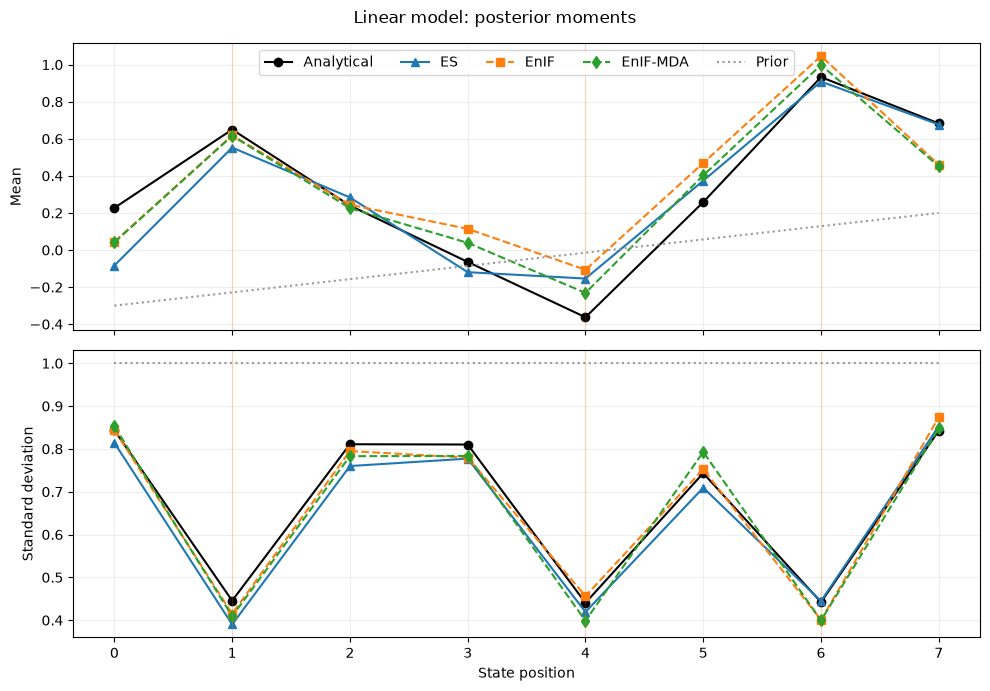

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
series = ((analytic_mean, es_mean, enif_mean, mda_mean, PRIOR_MEAN),
          (analytic_std, es_std, enif_std, mda_std, np.sqrt(np.diag(PRIOR_COV))))
for ax, (exact, es, single, multiple, prior), ylabel in zip(
        axes, series, ('Mean', 'Standard deviation')):
    ax.plot(positions, exact, 'k-o', label='Analytical')
    ax.plot(positions, es, '^-', label='ES')
    ax.plot(positions, single, 's--', label='EnIF')
    ax.plot(positions, multiple, 'd--', label='EnIF-MDA')
    ax.plot(positions, prior, ':', color='0.6', label='Prior')
    for i in OBS_INDEX:
        ax.axvline(i, color='tab:orange', lw=0.8, alpha=0.25)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
axes[0].legend(ncol=5)
axes[1].set_xlabel('State position')
axes[1].set_xticks(positions)
fig.suptitle('Linear model: posterior moments')
plt.tight_layout()
plt.show()


## Interpretation and an experiment

All three methods target the same analytical posterior here. ES uses finite-ensemble dense sample covariances, while EnIF learns a sparse response map and graph-constrained prior precision. Five uninflated EnIF updates would count the observations five times and over-contract the ensemble; EnIF-MDA avoids that by using the weights and carrying posterior information forward.

**Try:** Replace `WEIGHTS` with `[2, 4, 4]`, rerun from the MDA cell, and compare the summary. Check that $1/2+1/4+1/4=1$. Or set `MEMBERS` lower, rerun from the setup, and watch sampling error increase.